In [1]:
import pandas as pd
import numpy as np

In [2]:
import os

os.listdir("../data/processed")

['bluestock_mf_dashboard.pbix',
 'clean_aum_by_fund_house.csv',
 'clean_benchmark_indices.csv',
 'clean_category_inflows.csv',
 'clean_fund_master.csv',
 'clean_industry_folio_count.csv',
 'clean_investor_transactions.csv',
 'clean_monthly_sip_inflows.csv',
 'clean_nav_history.csv',
 'clean_portfolio_holdings.csv',
 'clean_scheme_performance.csv']

In [3]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

print(nav.columns.tolist())
nav.head()

['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")

print(fund_master.columns.tolist())

fund_master.head()

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
nav['date'] = pd.to_datetime(nav['date'])

data = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

data = data.sort_values(['scheme_name', 'date'])

data['daily_return'] = data.groupby('scheme_name')['nav'].pct_change()

results = []

for scheme, group in data.groupby('scheme_name'):

    returns = group['daily_return'].dropna()

    if len(returns) > 30:

        var_95 = returns.quantile(0.05)

        cvar_95 = returns[returns <= var_95].mean()

        results.append({
            'scheme_name': scheme,
            'VaR_95': round(var_95, 6),
            'CVaR_95': round(cvar_95, 6)
        })

var_cvar_report = pd.DataFrame(results)

var_cvar_report.head()

,scheme_name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [7]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [8]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'benchmark_comparison.png',
 'data_dictionary.md',
 'fund_scorecard.csv',
 'tracking_error.csv',
 'var_cvar_report.csv']

In [9]:
data['scheme_name'].nunique()

40

In [10]:
data[['scheme_name','date','daily_return']].head()

,scheme_name,date,daily_return
3450,ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,NaN
3451,ABSL Frontline Equity Fund - Regular - Growth,2022-01-04,0.001153
3452,ABSL Frontline Equity Fund - Regular - Growth,2022-01-05,0.003866
3453,ABSL Frontline Equity Fund - Regular - Growth,2022-01-06,-0.002128
3454,ABSL Frontline Equity Fund - Regular - Growth,2022-01-07,-0.006314


In [11]:
rolling_sharpe_list = []

for scheme, group in data.groupby('scheme_name'):

    group = group.sort_values('date').copy()

    group['rolling_sharpe'] = (
        group['daily_return'].rolling(90).mean()
        /
        group['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_list.append(group)

rolling_sharpe_df = pd.concat(rolling_sharpe_list)

print("Number of schemes:", rolling_sharpe_df['scheme_name'].nunique())

rolling_sharpe_df.head()

Number of schemes: 40


,amfi_code,date,nav,scheme_name,daily_return,rolling_sharpe
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153,NaN
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866,NaN
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128,NaN
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314,NaN


In [12]:
rolling_sharpe_df['scheme_name'].drop_duplicates().head(5)

3450     ABSL Frontline Equity Fund - Regular - Growth
5750               ABSL Liquid Fund - Regular - Growth
4600            ABSL Small Cap Fund - Regular - Growth
17250             Axis Bluechip Fund - Direct - Growth
16100            Axis Bluechip Fund - Regular - Growth
Name: scheme_name, dtype: str

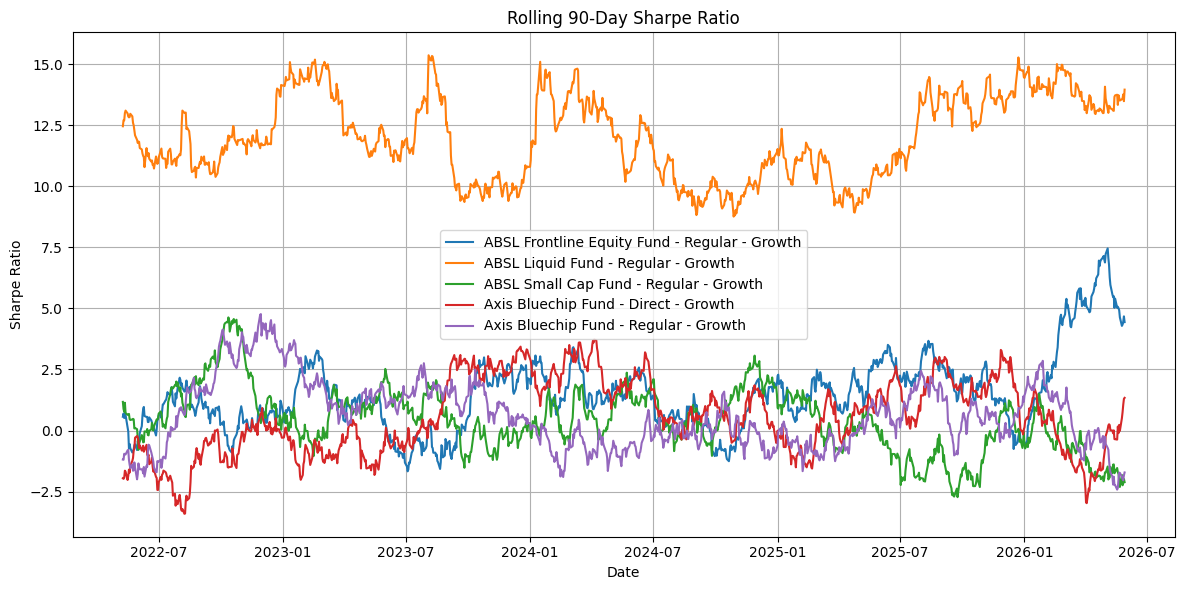

In [ ]:
import matplotlib.pyplot as plt

top5_funds = [
    "ABSL Frontline Equity Fund - Regular - Growth",
    "ABSL Liquid Fund - Regular - Growth",
    "ABSL Small Cap Fund - Regular - Growth",
    "Axis Bluechip Fund - Direct - Growth",
    "Axis Bluechip Fund - Regular - Growth"
]

plot_data = rolling_sharpe_df[
    rolling_sharpe_df['scheme_name'].isin(top5_funds)
]

plt.figure(figsize=(12,6))

for fund in top5_funds:
    temp = plot_data[plot_data['scheme_name'] == fund]
    plt.plot(temp['date'], temp['rolling_sharpe'], label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [14]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'benchmark_comparison.png',
 'data_dictionary.md',
 'fund_scorecard.csv',
 'rolling_sharpe_chart.png',
 'tracking_error.csv',
 'var_cvar_report.csv']

In [15]:
investors = pd.read_csv("../data/processed/clean_investor_transactions.csv")

print(investors.columns.tolist())
investors.head()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [16]:
investors['transaction_date'] = pd.to_datetime(
    investors['transaction_date']
)

cohort = (
    investors.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

cohort['cohort_year'] = cohort['transaction_date'].dt.year

cohort.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [17]:
investors = investors.merge(
    cohort[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

investors[['investor_id', 'cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [18]:
sip_data = investors[
    investors['transaction_type'] == 'Sip'
]

avg_sip = (
    sip_data.groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index(name='avg_sip_amount')
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [19]:
total_invested = (
    investors.groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index(name='total_invested')
)

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [20]:
fund_master = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

fund_master = fund_master[
    ['amfi_code', 'scheme_name']
]

In [21]:
investors_fund = investors.merge(
    fund_master,
    on='amfi_code',
    how='left'
)

top_funds = (
    investors_fund.groupby(
        ['cohort_year', 'scheme_name']
    )
    .size()
    .reset_index(name='count')
)

top_funds = (
    top_funds.sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_funds

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [22]:
cohort_report = (
    avg_sip
    .merge(total_invested, on='cohort_year')
    .merge(
        top_funds[['cohort_year', 'scheme_name']],
        on='cohort_year'
    )
)

cohort_report.rename(
    columns={
        'scheme_name': 'top_fund_preference'
    },
    inplace=True
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [23]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully")

cohort_analysis.csv saved successfully


In [24]:
sip_txn = investors[
    investors['transaction_type'] == 'Sip'
].copy()

sip_txn['transaction_date'] = pd.to_datetime(
    sip_txn['transaction_date']
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [25]:
sip_counts = (
    sip_txn.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible = sip_counts[
    sip_counts['sip_count'] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [26]:
sip_txn = sip_txn.merge(
    eligible[['investor_id']],
    on='investor_id',
    how='inner'
)

sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txn['gap_days'] = (
    sip_txn.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
1401,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
1899,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
2472,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
3602,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
8475,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [27]:
continuity = (
    sip_txn.groupby('investor_id')['gap_days']
    .mean()
    .reset_index(name='avg_gap_days')
)

continuity.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [28]:
continuity['status'] = np.where(
    continuity['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [29]:
continuity['status'].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [30]:
continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv saved successfully")

sip_continuity_report.csv saved successfully


In [31]:
scheme_perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print(scheme_perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [32]:
'risk_grade' in scheme_perf.columns

True

In [34]:
holdings = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

holdings.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [35]:
sector_weights = (
    holdings.groupby(['amfi_code', 'sector'])['weight_pct']
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [36]:
sector_weights['weight_share'] = (
    sector_weights['weight_pct'] / 100
)

sector_weights.head()

,amfi_code,sector,weight_pct,weight_share
0,100016,Automobile,14.84,0.1484
1,100016,Banking,3.39,0.0339
2,100016,Energy,6.09,0.0609
3,100016,FMCG,11.68,0.1168
4,100016,IT,25.90,0.2590


In [37]:
sector_weights['weight_sq'] = (
    sector_weights['weight_share'] ** 2
)

hhi_report = (
    sector_weights.groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
)

hhi_report.rename(
    columns={'weight_sq': 'HHI'},
    inplace=True
)

hhi_report.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [38]:
hhi_report = hhi_report.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

hhi_report.head()

,amfi_code,HHI,scheme_name
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth


In [39]:
hhi_report = hhi_report.sort_values(
    by='HHI',
    ascending=False
)

hhi_report.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth
32,149323,0.241077,DSP Midcap Fund - Regular - Growth
21,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth
10,118635,0.237497,Nippon India ETF Nifty 50 BeES
18,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth
22,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [40]:
hhi_report.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

print("hhi_concentration_report.csv saved successfully")

hhi_concentration_report.csv saved successfully


# Advanced Insights

## 1. Risk Analysis
Small-cap and equity-oriented funds exhibit the most negative VaR and CVaR values, indicating higher downside risk during adverse market conditions.

## 2. Risk-Adjusted Performance
Funds with the highest Sharpe ratios delivered superior risk-adjusted returns and form the basis of the recommendation engine.

## 3. Investor Cohorts
The 2024 investor cohort contributed the highest overall investment volume, while newer cohorts showed higher average SIP amounts.

## 4. SIP Continuity
A large number of investors were flagged as "At Risk" due to average SIP gaps exceeding 35 days, indicating potential future redemption or churn risk.

## 5. Portfolio Concentration
Funds with the highest HHI values have concentrated exposure to a limited number of sectors, whereas lower-HHI funds are more diversified and potentially less vulnerable to sector-specific shocks.